Imports

In [22]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt


In [23]:
df_analysis= pd.read_csv("oscars_movies_merged.csv")



In [24]:
df_analysis.groupby("oscar_nominated")["revenue"].mean()

oscar_nominated
False    1.320407e+08
True     3.396902e+08
Name: revenue, dtype: float64

In [25]:
df_analysis["log_revenue"] = np.log(df_analysis["revenue"])

In [26]:
df_analysis.groupby("oscar_nominated")["log_revenue"].mean()

oscar_nominated
False    17.337598
True     18.962000
Name: log_revenue, dtype: float64

In [27]:
df_analysis["budget_group"] = pd.qcut(df_analysis["budget"], 5)

In [28]:
df_analysis.groupby(
    ["budget_group","oscar_nominated"]
)["revenue"].mean()

budget_group               oscar_nominated
(0.999, 10000000.0]        False              2.022244e+07
                           True               5.947046e+07
(10000000.0, 22000000.0]   False              6.021727e+07
                           True               1.053610e+08
(22000000.0, 40000000.0]   False              8.634369e+07
                           True               1.767036e+08
(40000000.0, 85000000.0]   False              1.692183e+08
                           True               2.632983e+08
(85000000.0, 489900000.0]  False              4.273278e+08
                           True               6.476086e+08
Name: revenue, dtype: float64

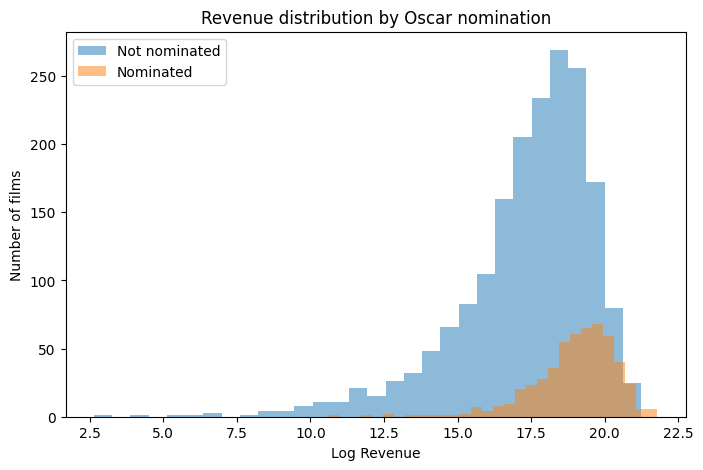

In [29]:
plt.figure(figsize=(8,5))

for value, group in df_analysis.groupby("oscar_nominated"):
    
    label = "Nominated" if value else "Not nominated"
    
    plt.hist(
        group["log_revenue"],
        bins=30,
        alpha=0.5,
        label=label
    )

plt.xlabel("Log Revenue")
plt.ylabel("Number of films")
plt.title("Revenue distribution by Oscar nomination")

plt.legend()
plt.show()

In [30]:
df_analysis.groupby("oscar_nominated")["revenue"].mean()

oscar_nominated
False    1.320407e+08
True     3.396902e+08
Name: revenue, dtype: float64

In [31]:
df_analysis.groupby("oscar_nominated")["log_revenue"].mean()

oscar_nominated
False    17.337598
True     18.962000
Name: log_revenue, dtype: float64

In [32]:
revenue_budget_oscar = (
    df_analysis
    .groupby(["budget_group", "oscar_nominated"])["revenue"]
    .mean()
    .unstack()
)

revenue_budget_oscar

oscar_nominated,False,True
budget_group,,
"(0.999, 10000000.0]",2.022244e+07,5.947046e+07
"(10000000.0, 22000000.0]",6.021727e+07,1.053610e+08
"(22000000.0, 40000000.0]",8.634369e+07,1.767036e+08
"(40000000.0, 85000000.0]",1.692183e+08,2.632983e+08
"(85000000.0, 489900000.0]",4.273278e+08,6.476086e+08


In [33]:
revenue_budget_oscar_median = (
    df_analysis
    .groupby(["budget_group", "oscar_nominated"])["revenue"]
    .median()
    .unstack()
)

revenue_budget_oscar_median

oscar_nominated,False,True
budget_group,,
"(0.999, 10000000.0]",5800404.5,33965843.0
"(10000000.0, 22000000.0]",33455481.0,63647656.0
"(22000000.0, 40000000.0]",61601280.0,134100000.0
"(40000000.0, 85000000.0]",134748021.0,210358108.0
"(85000000.0, 489900000.0]",347325802.0,529323962.0


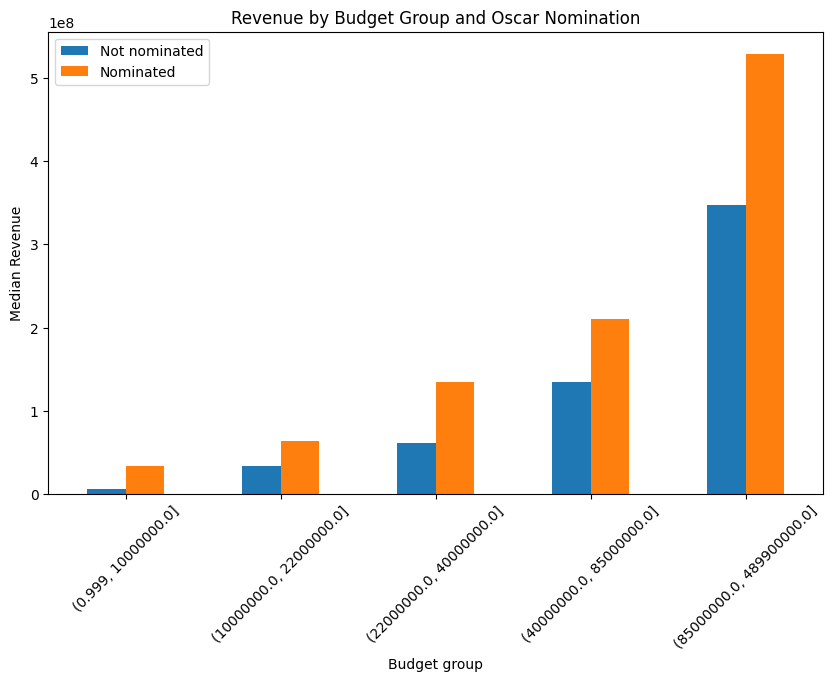

In [34]:
revenue_budget_oscar_median.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Median Revenue")
plt.xlabel("Budget group")
plt.title("Revenue by Budget Group and Oscar Nomination")

plt.xticks(rotation=45)
plt.legend(["Not nominated", "Nominated"])

plt.show()

When comparing films within the same budget groups, nominated films consistently show higher median box office revenues than non-nominated films. This suggests that Academy Award recognition is associated with higher commercial performance.

In [35]:
df_analysis["roi"] = df_analysis["revenue"] / df_analysis["budget"]

In [36]:
df_analysis["roi"] = df_analysis["revenue"] / df_analysis["budget"]

In [37]:
roi_budget_oscar = (
    df_analysis
    .groupby(["budget_group", "oscar_nominated"])["roi"]
    .median()
    .unstack()
)

roi_budget_oscar

oscar_nominated,False,True
budget_group,,
"(0.999, 10000000.0]",1.803835,5.923191
"(10000000.0, 22000000.0]",2.061841,3.612906
"(22000000.0, 40000000.0]",2.068099,4.670662
"(40000000.0, 85000000.0]",2.229530,3.491030
"(85000000.0, 489900000.0]",2.429885,3.594725


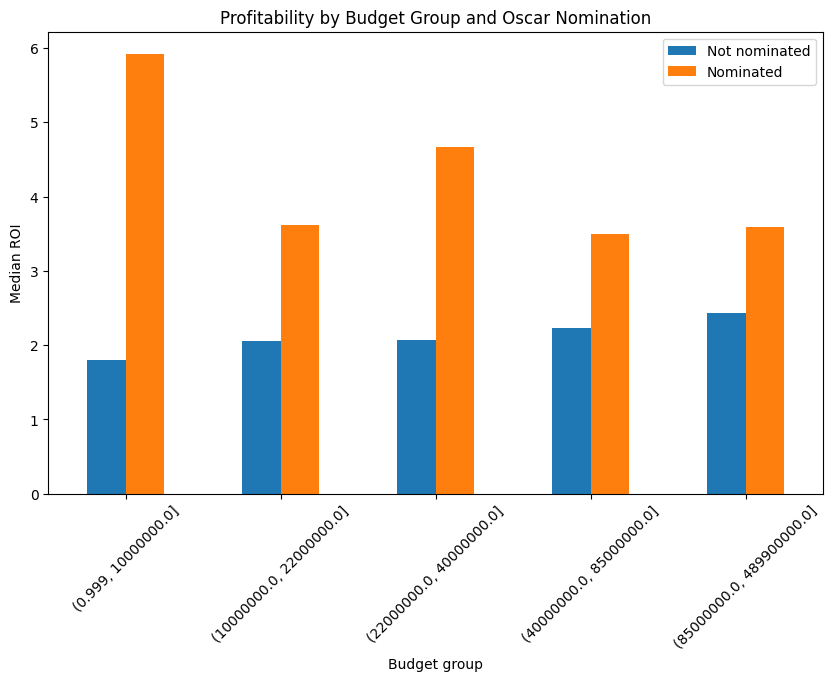

In [38]:
roi_budget_oscar.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Median ROI")
plt.xlabel("Budget group")
plt.title("Profitability by Budget Group and Oscar Nomination")

plt.xticks(rotation=45)
plt.legend(["Not nominated", "Nominated"])

plt.show()

The analysis shows that films receiving an Academy Award nomination tend to achieve higher profitability across all budget groups. For example, low-budget nominated films have a median return on investment (ROI) of approximately 5.9, compared to about 1.8 for non-nominated films.

A similar pattern appears across medium and high budget categories, where nominated films consistently exhibit higher ROI values. The difference is particularly pronounced for lower-budget productions, suggesting that Oscar recognition may significantly enhance the commercial performance of smaller films.